In [5]:
!pip install pandas lifelines matplotlib

import pandas as pd

df = pd.read_csv("cgga.csv", sep=';')

df = df.rename(columns={
    "Censor (alive=0; dead=1)": "Censor",
    "Radio_status (treated=1;un-treated=0)": "Radio_status",
    "Chemo_status (TMZ treated=1;un-treated=0)": "Chemo_status",
    "IDH_mutation_status": "IDH_status",
    "MGMTp_methylation_status": "MGMT_status", "Grade": "Grade"
})

In [7]:
df["OS"] = pd.to_numeric(df["OS"], errors="coerce")

df["Censor"] = pd.to_numeric(df["Censor"], errors="coerce")

df["Age"] = pd.to_numeric(df["Age"], errors="coerce")

Unique grades: ['WHO IV' 'WHO II' 'WHO III']
Total rows after cleaning: 282
WHO II n = 106
WHO III n = 53
WHO IV n = 123


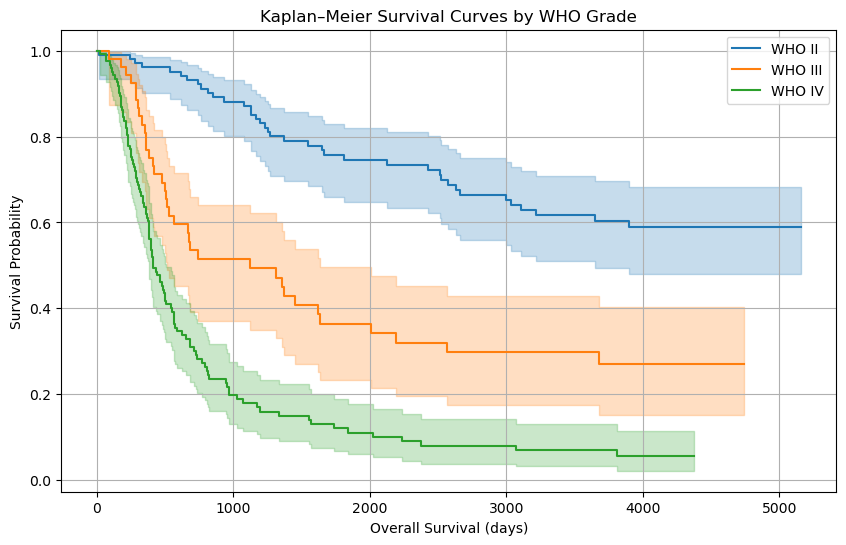

In [9]:
import matplotlib.pyplot as plt
from lifelines import KaplanMeierFitter

df_grade = df[df["Grade"].isin(["WHO II", "WHO III", "WHO IV"])].copy()

df_grade = df_grade.dropna(subset=["OS", "Censor"])

print("Unique grades:", df_grade["Grade"].unique())
print("Total rows after cleaning:", len(df_grade))

kmf = KaplanMeierFitter()
plt.figure(figsize=(10,6))

for grade in ["WHO II", "WHO III", "WHO IV"]:
    group = df_grade[df_grade["Grade"] == grade].copy()
    print(grade, "n =", len(group))
    kmf.fit(group["OS"], event_observed=group["Censor"], label=grade)
    kmf.plot_survival_function(ci_show=True)

plt.title("Kaplan–Meier Survival Curves by WHO Grade")
plt.xlabel("Overall Survival (days)")
plt.ylabel("Survival Probability")
plt.grid(True)
plt.show()

In [13]:
from lifelines.statistics import multivariate_logrank_test

results = multivariate_logrank_test(
    df_grade["OS"], 
    df_grade["Grade"], 
    df_grade["Censor"]
)

results.print_summary()

<lifelines.StatisticalResult: multivariate_logrank_test>
               t_0 = -1
 null_distribution = chi squared
degrees_of_freedom = 2
         test_name = multivariate_logrank_test

---
 test_statistic      p  -log2(p)
         122.07 <0.005     88.06

In [21]:
from lifelines import CoxPHFitter
import pandas as pd

def make_gender_bin(df, gender_col="Gender"):
    df = df.copy()
    df["Gender_bin"] = df[gender_col].apply(lambda x: 1 if str(x).strip().lower() == "male" else 0)
    return df

def compact_cox_table(cph, decimals_hr_ci=2, decimals_p=3):
    s = cph.summary.copy()
    out = pd.DataFrame({
        "HR": s["exp(coef)"],
        "CI 95% (lower)": s["exp(coef) lower 95%"],
        "CI 95% (upper)": s["exp(coef) upper 95%"],
        "p-value": s["p"],
    })
    out = out.round({
        "HR": decimals_hr_ci,
        "CI 95% (lower)": decimals_hr_ci,
        "CI 95% (upper)": decimals_hr_ci,
        "p-value": decimals_p,
    })
    return out

def print_fit_stats(cph, label=""):
    lrt = cph.log_likelihood_ratio_test()
    if label:
        print(f"\n{label}")
    print(f"Concordance (C-index): {cph.concordance_index_:.2f}")
    print(f"Log-likelihood ratio test: {lrt.test_statistic:.2f} on {lrt.degrees_freedom} df (p = {lrt.p_value:.2e})")

def fit_cox_overall(df, duration_col="OS", event_col="Censor"):
    df = df.copy()

    df[duration_col] = pd.to_numeric(df[duration_col], errors="coerce")
    df[event_col] = pd.to_numeric(df[event_col], errors="coerce")

    df = make_gender_bin(df, gender_col="Gender")
    df = pd.get_dummies(df, columns=["Grade"], drop_first=True)

    covariates = ["Age", "Gender_bin", "Grade_WHO III", "Grade_WHO IV"]
    needed = [duration_col, event_col] + covariates

    df_clean = df.dropna(subset=needed).copy()

    cph = CoxPHFitter()
    cph.fit(df_clean[needed], duration_col=duration_col, event_col=event_col)
    return cph, df_clean

def fit_cox_within_grade(df, grade_value, duration_col="OS", event_col="Censor"):
    df_g = df[df["Grade"] == grade_value].copy()

    df_g[duration_col] = pd.to_numeric(df_g[duration_col], errors="coerce")
    df_g[event_col] = pd.to_numeric(df_g[event_col], errors="coerce")

    df_g = make_gender_bin(df_g, gender_col="Gender")

    covariates = ["Age", "Gender_bin"]
    needed = [duration_col, event_col] + covariates

    df_g_clean = df_g.dropna(subset=needed).copy()

    cph = CoxPHFitter()
    cph.fit(df_g_clean[needed], duration_col=duration_col, event_col=event_col)
    return cph, df_g_clean

cph_overall, df_overall_clean = fit_cox_overall(df, duration_col="OS", event_col="Censor")

overall_table = compact_cox_table(cph_overall)
display(overall_table)

print_fit_stats(cph_overall, label="Overall Cox model fit statistics")

within_models = {}
for g in ["WHO II", "WHO III", "WHO IV"]:
    cph_g, df_g_clean = fit_cox_within_grade(df, grade_value=g, duration_col="OS", event_col="Censor")
    within_models[g] = cph_g

    print("\n" + "=" * 60)
    print(f"Within-grade Cox model: {g}")
    display(compact_cox_table(cph_g))
    print_fit_stats(cph_g, label="Fit statistics")

,HR,CI 95% (lower),CI 95% (upper),p-value
covariate,,,,
Age,1.02,1.01,1.03,0.004
Gender_bin,1.19,0.88,1.60,0.253
Grade_WHO III,2.57,1.63,4.05,0.000
Grade_WHO IV,5.42,3.67,8.00,0.000



Overall Cox model fit statistics
Concordance (C-index): 0.73
Log-likelihood ratio test: 117.47 on 4 df (p = 1.85e-24)

Within-grade Cox model: WHO II


,HR,CI 95% (lower),CI 95% (upper),p-value
covariate,,,,
Age,1.04,1.00,1.08,0.027
Gender_bin,1.56,0.81,3.01,0.184



Fit statistics
Concordance (C-index): 0.63
Log-likelihood ratio test: 6.12 on 2 df (p = 4.70e-02)

Within-grade Cox model: WHO III


,HR,CI 95% (lower),CI 95% (upper),p-value
covariate,,,,
Age,1.02,0.99,1.05,0.179
Gender_bin,0.74,0.38,1.43,0.373



Fit statistics
Concordance (C-index): 0.54
Log-likelihood ratio test: 2.32 on 2 df (p = 3.14e-01)

Within-grade Cox model: WHO IV


,HR,CI 95% (lower),CI 95% (upper),p-value
covariate,,,,
Age,1.01,1.00,1.03,0.085
Gender_bin,1.25,0.84,1.86,0.265



Fit statistics
Concordance (C-index): 0.56
Log-likelihood ratio test: 4.30 on 2 df (p = 1.16e-01)
